### Basic functions

In [1]:
import numpy as np
import pandas as pd
import time
import random
import statistics as stats
from sko.PSO import PSO
import matplotlib.pyplot as plt
from sko.DE import DE
np.random.seed(42)
random.seed(42)

# Function definitions
def rosenbrock(x):
    return sum(100.0 * (x[1:] - x[:-1]**2.0)**2.0 + (1 - x[:-1])**2.0)

def griewank(x):
    part1 = sum(x**2) / 4000.0
    part2 = np.prod(np.cos(x / np.sqrt(np.arange(1, len(x) + 1))))
    return 1.0 + part1 - part2

# sweep function
def run_experiment(algo_type, func, n_dim, lb, ub, params, rounds=30, max_iter=500, pop=50):
    all_best_histories = []
    all_avg_histories = []
    final_errors = []
    
    for r in range(rounds):
        if algo_type == 'PSO':
            model = PSO(func=func, n_dim=n_dim, pop=pop, max_iter=max_iter, 
                        lb=lb, ub=ub, w=params['w'], c1=params['c1'], c2=params['c2'])
        elif algo_type == 'DE':
            model = DE(func=func, n_dim=n_dim, size_pop=pop, max_iter=max_iter, 
                       lb=lb, ub=ub, F=params['F'], CR=params['CR'])
        
        model.record_mode = True
        model.run()
        
        # Error final d'aquesta ronda
        final_val = model.gbest_y[0] if algo_type == 'PSO' else model.fun
        final_errors.append(final_val)
        
        # Historial d'aquesta ronda
        X_history = model.record_value['X']
        round_best = []
        round_avg = []
        for pop_X in X_history:
            fits = np.array([func(ind) for ind in pop_X])
            round_best.append(np.min(fits))
            round_avg.append(np.mean(fits))
            
        all_best_histories.append(round_best)
        all_avg_histories.append(round_avg)

    # Convertim a arrays per calcular mètriques per iteració
    all_best_h = np.array(all_best_histories)
    all_avg_h = np.array(all_avg_histories)
    
    # Calculem les mitjanes per al plot
    avg_min_fit = np.mean(all_best_h, axis=0)
    std_min_fit = np.std(all_best_h, axis=0)
    avg_pop_avg = np.mean(all_avg_h, axis=0)

    # Gràfic individual per a aquesta configuració
    plt.figure(figsize=(10, 5))
    iters = np.arange(len(avg_min_fit))
    plt.plot(iters, avg_pop_avg, label='Avg of Pop Avg', color='blue', linestyle='--', alpha=0.6)
    plt.plot(iters, avg_min_fit, label='Min Fit (Mean)', color='green', linewidth=2)
    
    # Ombra de la Std Dev envoltant el Min Fit
    plt.fill_between(iters, avg_min_fit - std_min_fit, avg_min_fit + std_min_fit, 
                     color='green', alpha=0.2, label='Std Dev (Min Fit)')
    
    plt.yscale('log')
    plt.title(f"Evolució {algo_type} - {params}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return {
        # Claus per al teu DataFrame/Llista (Fix del KeyError)
        'avg': np.mean(final_errors),
        'min': np.min(final_errors),
        'std': np.std(final_errors) if len(final_errors) > 1 else 0.0,
        
        # Dades guardades per al gràfic comparatiu final
        'hist_avg_min': avg_min_fit,
        'hist_std_min': std_min_fit
    }

def plot_final_comparison(results_master, var_name, filename="comparativa_final.png"):
    """Genera un sol gràfic amb totes les configuracions juntes."""
    plt.figure(figsize=(12, 7))
    colors = plt.cm.get_cmap('tab10', len(results_master))
    
    for i, (val, res) in enumerate(results_master.items()):
        iters = np.arange(len(res['hist_avg_min']))
        c = colors(i)
        
        plt.plot(iters, res['hist_avg_min'], label=f'{var_name}={val}', color=c, linewidth=2)
        plt.fill_between(iters, res['hist_avg_min'] - res['hist_std_min'], 
                         res['hist_avg_min'] + res['hist_std_min'], color=c, alpha=0.15)

    plt.yscale('log')
    plt.xlabel('Iteracions')
    plt.ylabel('Best Fitness (Log Scale)')
    plt.title(f'Comparativa d\'evolució segons {var_name}', fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, which="both", alpha=0.2)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

Initializing Parameter Sweep - Griewank 10D...

Trying PSO with these parameters -> w: 0.8, c1: 0.5, c2: 0.5...


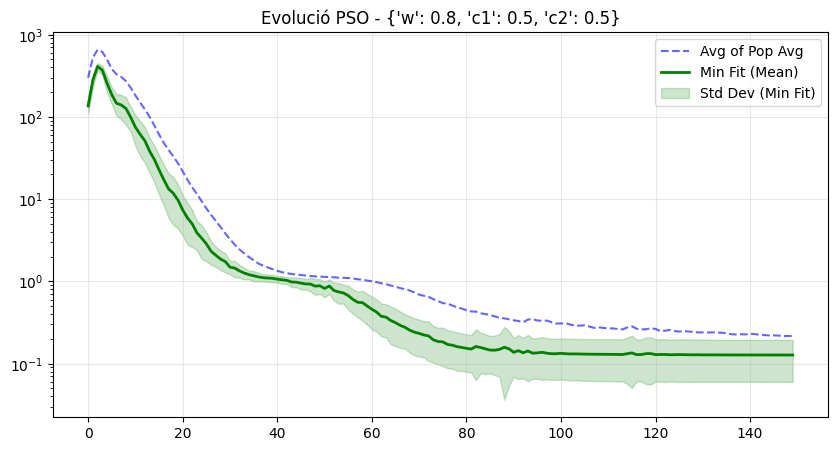

  -> Made in 6.92s | Avg: 0.1274 | Min: 0.0246 | Std: 0.0673

Trying PSO with these parameters -> w: 0.9, c1: 1.5, c2: 1.5...


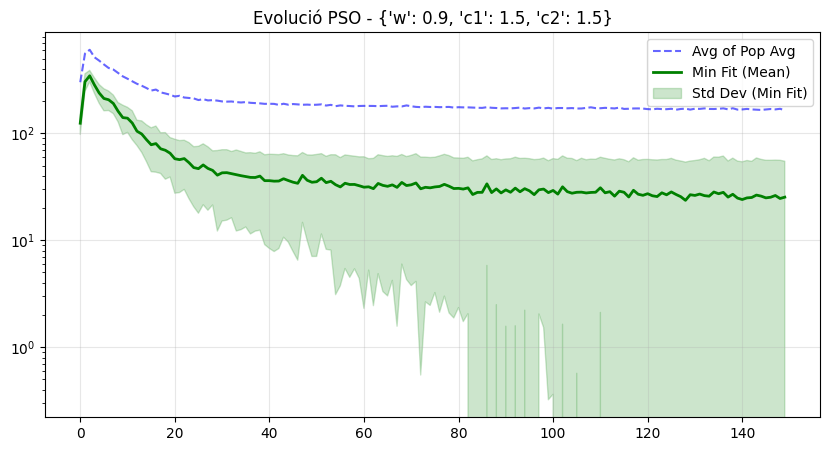

  -> Made in 6.88s | Avg: 16.9137 | Min: 1.9356 | Std: 29.5901

Trying PSO with these parameters -> w: 0.4, c1: 2.0, c2: 2.0...


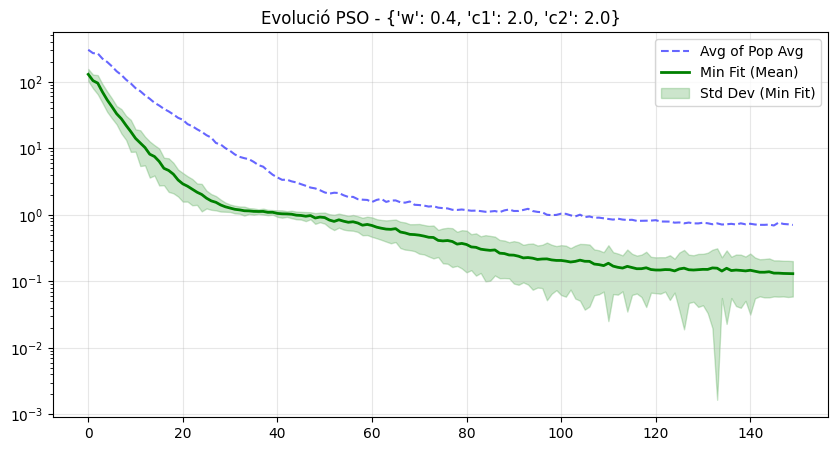

  -> Made in 7.01s | Avg: 0.1284 | Min: 0.0467 | Std: 0.0690

Trying PSO with these parameters -> w: 0.9, c1: 0.1, c2: 3.9...


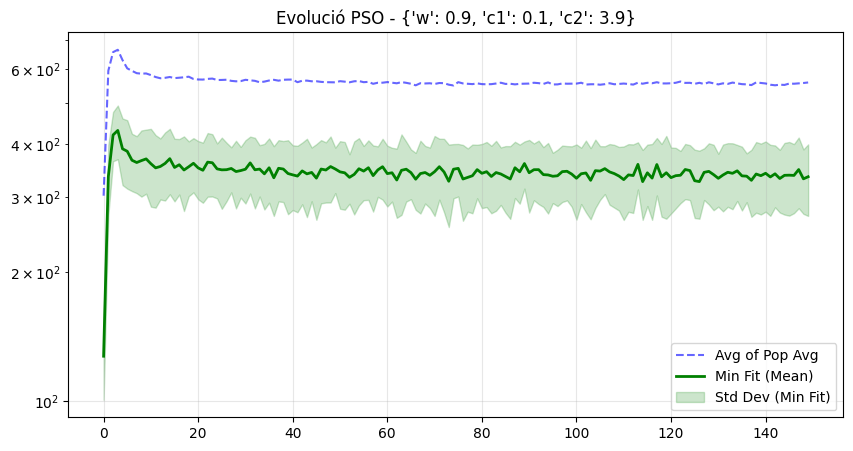

  -> Made in 6.89s | Avg: 248.1849 | Min: 120.2194 | Std: 62.6004

 RESULTS PSO - GRIEWANK 10D
Alg   w  c1  c2    Avg Fit    Min Fit   Std Dev
PSO 0.8 0.5 0.5   0.127351   0.024603  0.067314
PSO 0.9 1.5 1.5  16.913653   1.935629 29.590064
PSO 0.4 2.0 2.0   0.128370   0.046725  0.069007
PSO 0.9 0.1 3.9 248.184941 120.219395 62.600393


C:\Users\Enric\AppData\Local\Temp\ipykernel_1272\2132506841.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


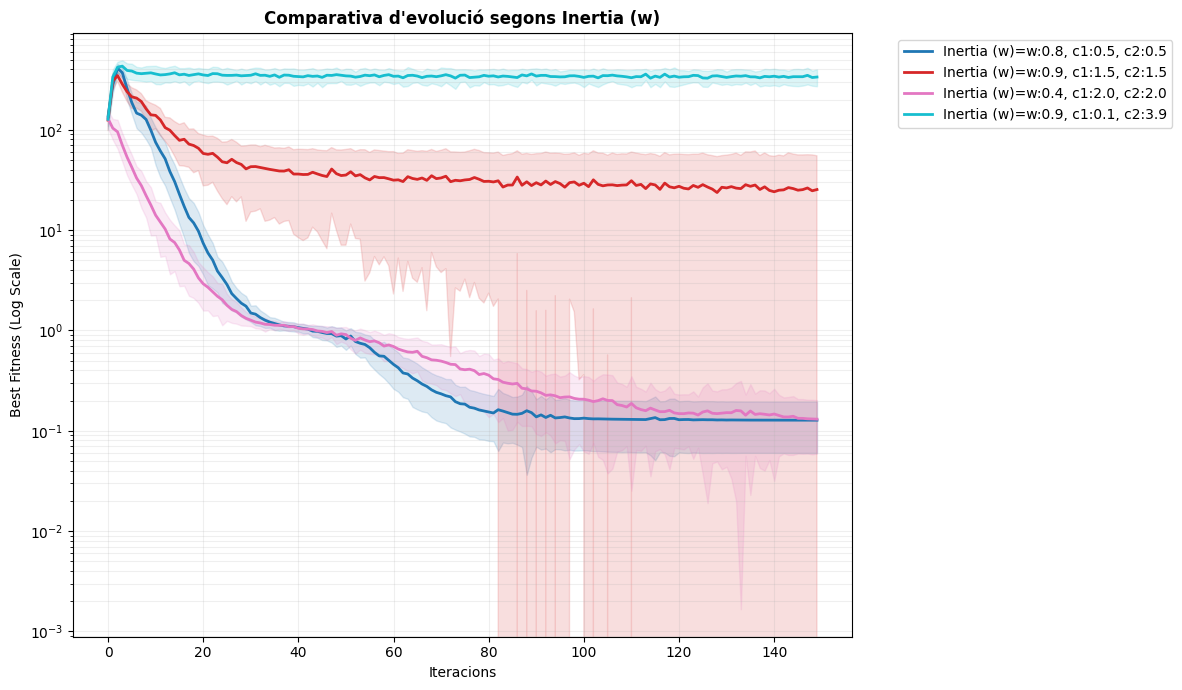

In [4]:
# Configuració bàsica
dimensions = 10
lower_bound = [-600] * dimensions # Límits típics per Griewank
upper_bound = [600] * dimensions
rounds_sweep = 30
def_pop = 50
def_iter = 150

results_pso = []
master_results = {}

print(f"Initializing Parameter Sweep - Griewank {dimensions}D...")

# Escombrat de Inèrcia (w) i Factors (c1, c2)
# Ens assegurem de complir Engelbrecht: c1 + c2 <= 4
configs = [
    {'w': 0.8, 'c1': 0.5, 'c2': 0.5}, # Exploració moderada
    {'w': 0.9, 'c1': 1.5, 'c2': 1.5}, # Exploració alta (c1+c2 = 3)
    {'w': 0.4, 'c1': 2.0, 'c2': 2.0}, # Convergència ràpida (c1+c2 = 4)
    {'w': 0.9, 'c1': 0.1, 'c2': 3.9}  # Molt social, poc cognitiu (c1+c2 = 4)
]

for cfg in configs:
    w, c1, c2 = cfg['w'], cfg['c1'], cfg['c2']
    print(f"\nTrying PSO with these parameters -> w: {w}, c1: {c1}, c2: {c2}...")
    start = time.time()
    result = run_experiment('PSO', griewank, dimensions, lower_bound, upper_bound, cfg, rounds_sweep, def_iter, def_pop)
    results_pso.append({'Alg': 'PSO', 'w': w, 'c1': c1, 'c2': c2, 'Avg Fit': result['avg'], 'Min Fit': result['min'], 'Std Dev': result['std']})
    label = f"w:{w}, c1:{c1}, c2:{c2}"
    master_results[label] = result
    print(f"  -> Made in {time.time()-start:.2f}s | Avg: {result['avg']:.4f} | Min: {result['min']:.4f} | Std: {result['std']:.4f}")

df_pso = pd.DataFrame(results_pso)
print("\n" + "="*70)
print(" RESULTS PSO - GRIEWANK " + str(dimensions) + "D")
print("="*70)
print(df_pso.to_string(index=False))

plot_final_comparison(master_results, var_name="Inertia (w)")

# RESULTS PSO – Griewank 4D

| Alg | w   | c1  | c2  | Avg Fit   | Min Fit   | Std Dev    |
|-----|-----|-----|-----|-----------|-----------|------------|
| PSO | 0.8 | 0.5 | 0.5 | 0.063249  | 0.007396  | 0.042981   |
| PSO | 0.9 | 1.5 | 1.5 | 0.497998  | 0.169217  | 0.187531   |
| PSO | 0.4 | 2.0 | 2.0 | 0.040728  | 0.000197  | 0.033747   |
| PSO | 0.9 | 0.1 | 3.9 | 20.525288 | 1.574204  | 36.021409  |


# RESULTS PSO – Griewank 10D

| Alg | w   | c1  | c2  | Avg Fit    | Min Fit    | Std Dev    |
|-----|-----|-----|-----|------------|------------|------------|
| PSO | 0.8 | 0.5 | 0.5 | 3.114372   | 0.022156   | 16.484783  |
| PSO | 0.9 | 1.5 | 1.5 | 11.788798  | 2.046498   | 22.545628  |
| PSO | 0.4 | 2.0 | 2.0 | 0.108321   | 0.029518   | 0.059157   |
| PSO | 0.9 | 0.1 | 3.9 | 249.808995 | 141.305900 | 43.947508  |


# RESULTS PSO – Griewank 100D

| Alg | w   | c1  | c2  | Avg Fit      | Min Fit      | Std Dev     |
|-----|-----|-----|-----|--------------|--------------|-------------|
| PSO | 0.8 | 0.5 | 0.5 | 2133.757807  | 1687.657781  | 193.442951  |
| PSO | 0.9 | 1.5 | 1.5 | 3759.174995  | 3438.487174  | 194.671215  |
| PSO | 0.4 | 2.0 | 2.0 | 534.156155   | 311.955678   | 117.265123  |
| PSO | 0.9 | 0.1 | 3.9 | 5137.968269  | 4663.196001  | 189.270367  |


Initializing Parameter Sweep - Griewank 10D...

Trying PSO with these parameters -> w: 0.4, c1: 2.0, c2: 2.0...


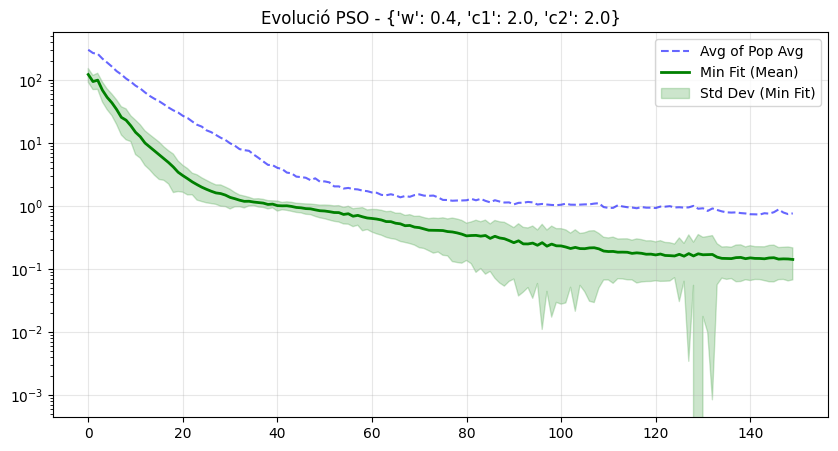

  -> Fet en 7.52s | Avg: 0.1375 | Min: 0.0099 | Std: 0.0719

Trying PSO with these parameters -> w: 0.5, c1: 2.0, c2: 2.0...


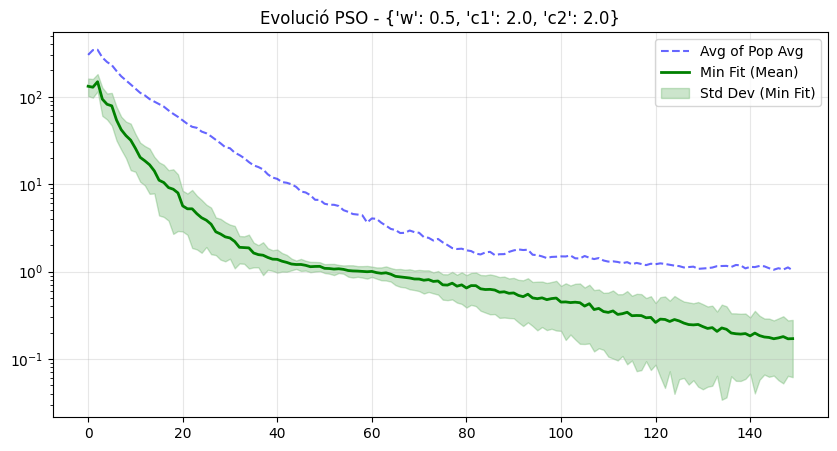

  -> Fet en 7.24s | Avg: 0.1597 | Min: 0.0439 | Std: 0.0955

Trying PSO with these parameters -> w: 0.3, c1: 2.0, c2: 2.0...


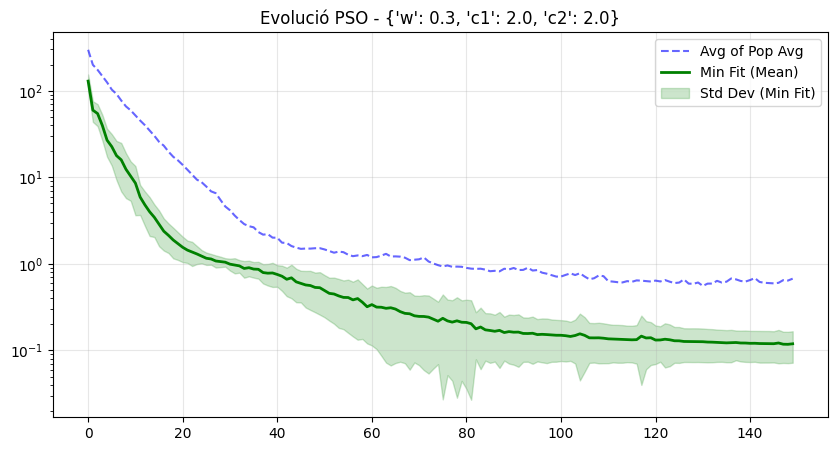

  -> Fet en 9.34s | Avg: 0.1175 | Min: 0.0443 | Std: 0.0464

Trying PSO with these parameters -> w: 0.4, c1: 1.5, c2: 2.5...


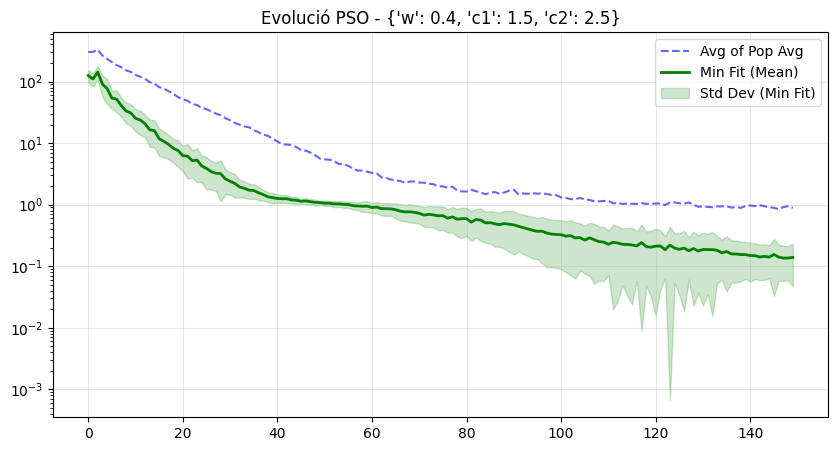

  -> Fet en 7.21s | Avg: 0.1320 | Min: 0.0099 | Std: 0.0726

Trying PSO with these parameters -> w: 0.4, c1: 2.5, c2: 1.5...


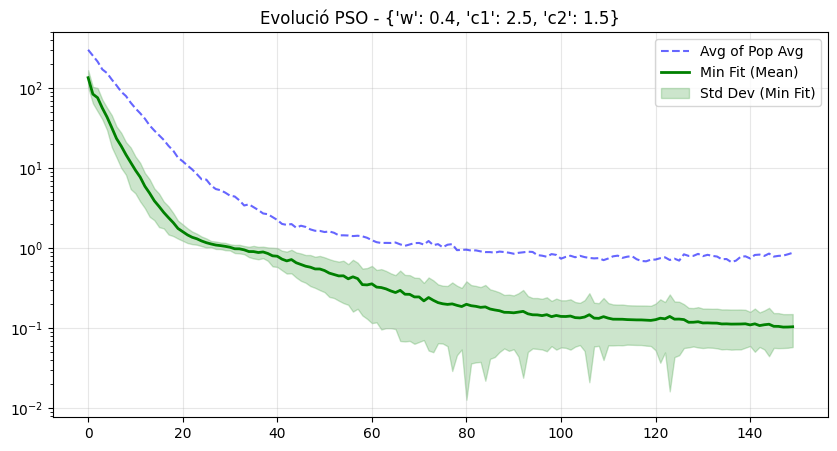

  -> Fet en 6.68s | Avg: 0.1007 | Min: 0.0080 | Std: 0.0445

Trying PSO with these parameters -> w: 0.5, c1: 1.5, c2: 1.5...


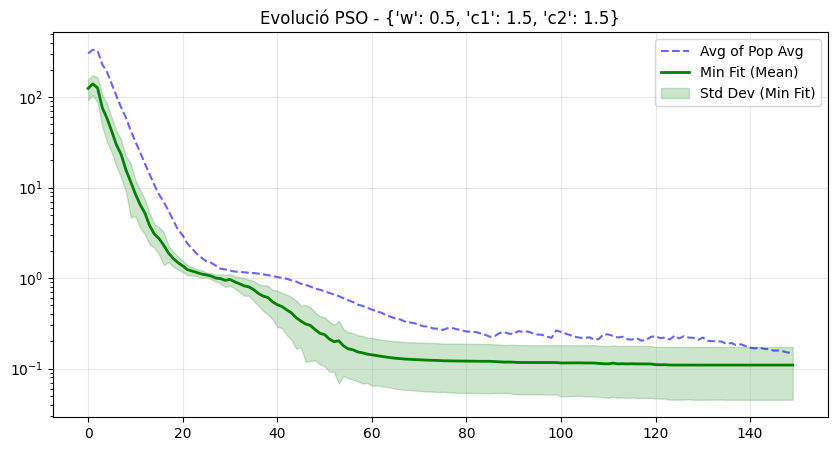

  -> Fet en 7.01s | Avg: 0.1093 | Min: 0.0246 | Std: 0.0641

 RESULTS PSO - GRIEWANK 10D
Alg   w  c1  c2  Avg Fit  Min Fit  Std Dev
PSO 0.4 2.0 2.0 0.137451 0.009858 0.071855
PSO 0.5 2.0 2.0 0.159696 0.043897 0.095467
PSO 0.3 2.0 2.0 0.117501 0.044271 0.046422
PSO 0.4 1.5 2.5 0.132031 0.009865 0.072556
PSO 0.4 2.5 1.5 0.100664 0.008029 0.044504
PSO 0.5 1.5 1.5 0.109339 0.024603 0.064116


C:\Users\Enric\AppData\Local\Temp\ipykernel_1272\2132506841.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


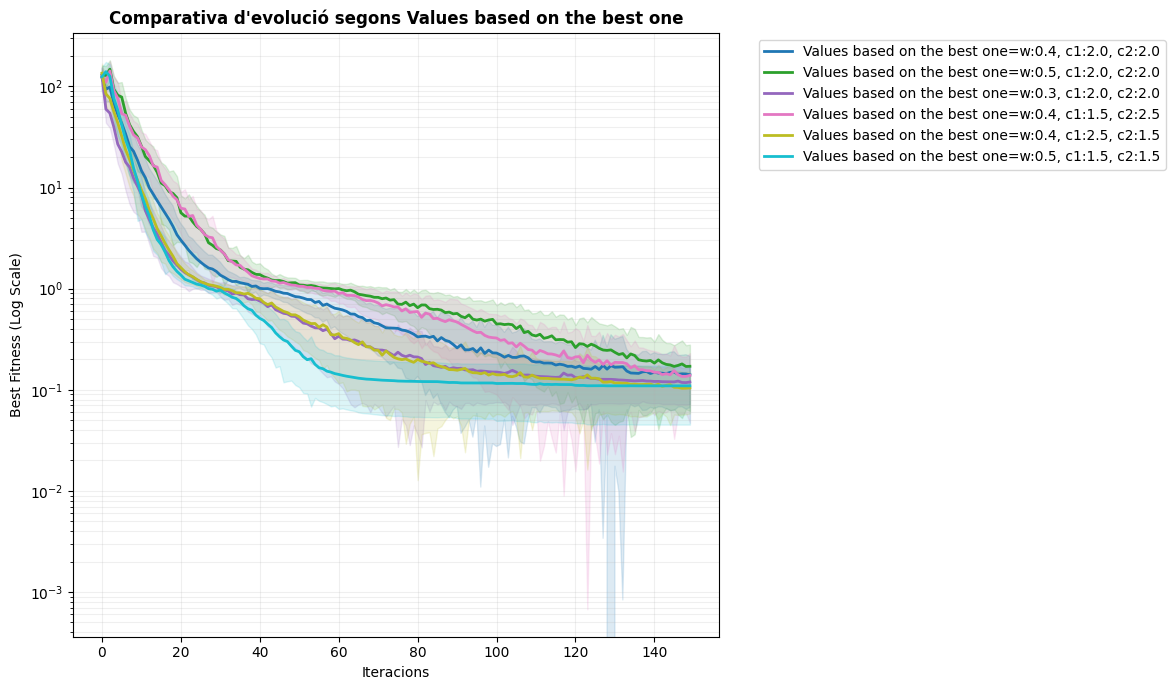

In [5]:
# Configuració bàsica
dimensions = 10
lower_bound = [-600] * dimensions # Límits típics per Griewank
upper_bound = [600] * dimensions
rounds_sweep = 30
def_pop = 50
def_iter = 150

results_pso = []
master_results = {}

print(f"Initializing Parameter Sweep - Griewank {dimensions}D...")

# Escombrat de Inèrcia (w) i Factors (c1, c2)
# Ens assegurem de complir Engelbrecht: c1 + c2 <= 4
configs_expandida = [
    {'w': 0.4, 'c1': 2.0, 'c2': 2.0},  # Actual guanyador
    {'w': 0.5, 'c1': 2.0, 'c2': 2.0},  # Més inèrcia
    {'w': 0.3, 'c1': 2.0, 'c2': 2.0},  # Menys inèrcia
    {'w': 0.4, 'c1': 1.5, 'c2': 2.5},  # Més social
    {'w': 0.4, 'c1': 2.5, 'c2': 1.5},  # Més cognitiu
    {'w': 0.5, 'c1': 1.5, 'c2': 1.5},  # Balancejat
]

for cfg in configs_expandida:
    w, c1, c2 = cfg['w'], cfg['c1'], cfg['c2']
    print(f"\nTrying PSO with these parameters -> w: {w}, c1: {c1}, c2: {c2}...")
    start = time.time()
    result = run_experiment('PSO', griewank, dimensions, lower_bound, upper_bound, cfg, rounds_sweep, def_iter, def_pop)
    results_pso.append({'Alg': 'PSO', 'w': w, 'c1': c1, 'c2': c2, 'Avg Fit': result['avg'], 'Min Fit': result['min'], 'Std Dev': result['std']})
    label = f"w:{w}, c1:{c1}, c2:{c2}"
    master_results[label] = result
    print(f"  -> Made in {time.time()-start:.2f}s | Avg: {result['avg']:.4f} | Min: {result['min']:.4f} | Std: {result['std']:.4f}")

df_pso2 = pd.DataFrame(results_pso)
print("\n" + "="*70)
print(" RESULTS PSO - GRIEWANK " + str(dimensions) + "D")
print("="*70)
print(df_pso2.to_string(index=False))

plot_final_comparison(master_results, var_name="Values based on the best one")

Initializing Parameter Sweep - Griewank 10D, w = 0.4, c1 = 2.5, c2 = 1.5...

Trying PSO with population 30


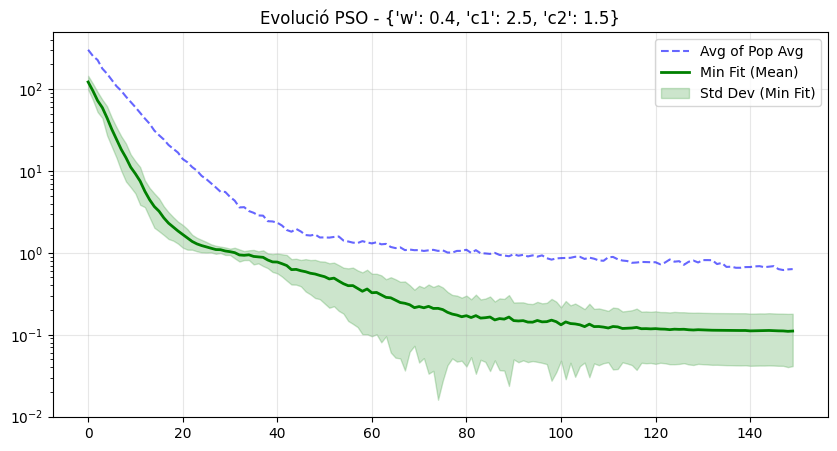

  -> Made in 8.10s | Avg: 0.1100 | Min: 0.0370 | Std: 0.0698

Trying PSO with population 50


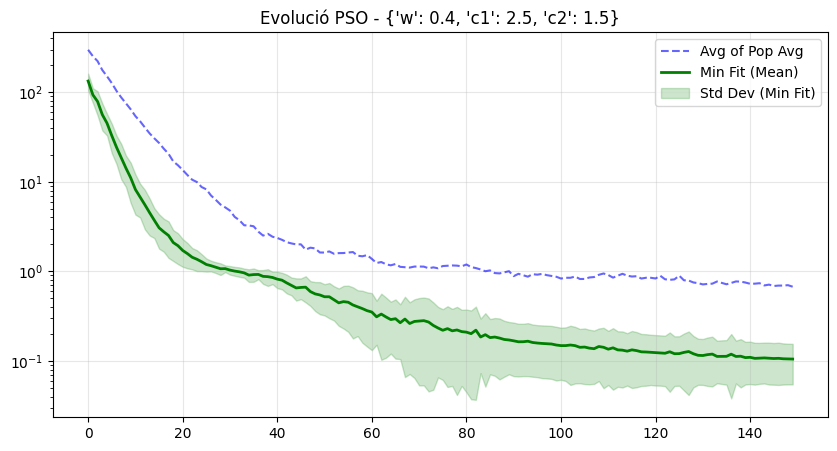

  -> Made in 8.37s | Avg: 0.1046 | Min: 0.0222 | Std: 0.0500

Trying PSO with population 100


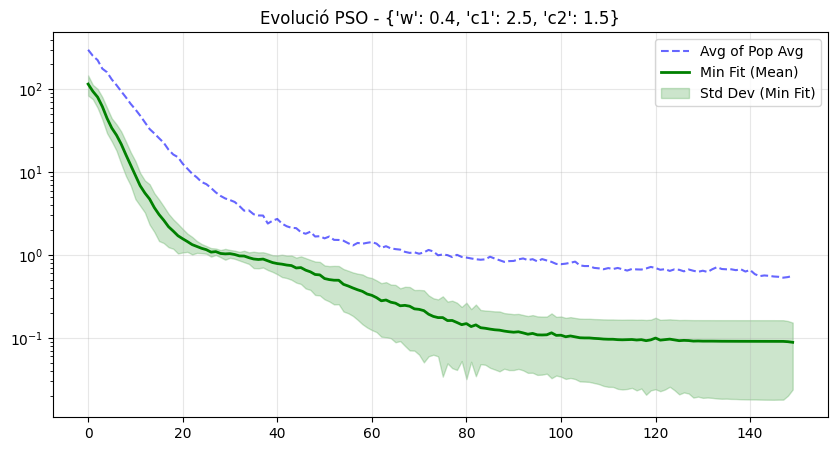

  -> Made in 8.30s | Avg: 0.0881 | Min: 0.0074 | Std: 0.0644

Trying PSO with population 150


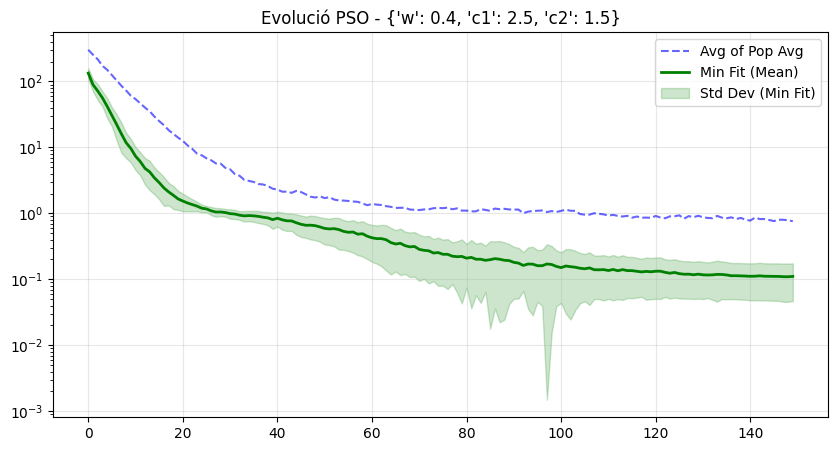

  -> Made in 8.38s | Avg: 0.1092 | Min: 0.0123 | Std: 0.0641

Trying PSO with population 250


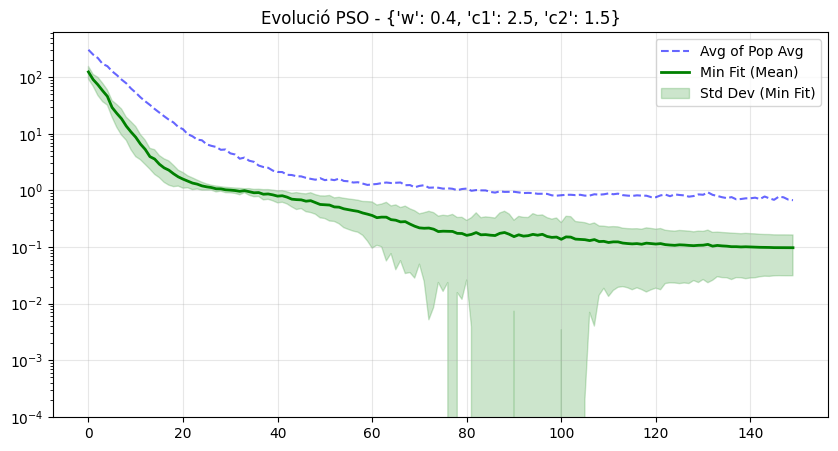

  -> Made in 8.05s | Avg: 0.0971 | Min: 0.0000 | Std: 0.0660

Trying PSO with population 400


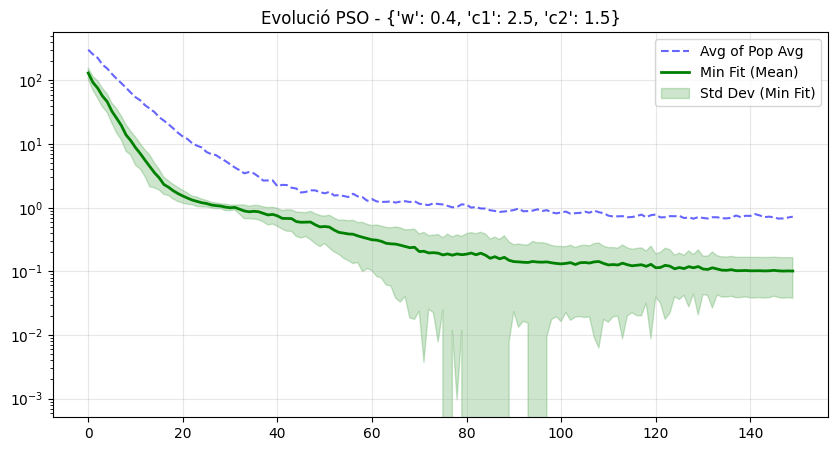

  -> Made in 10.38s | Avg: 0.1007 | Min: 0.0320 | Std: 0.0633

 RESULTS PSO - GRIEWANK 10D
Alg  population  Avg Fit  Min Fit  Std Dev
PSO          30 0.110041 0.036961 0.069791
PSO          50 0.104641 0.022186 0.049965
PSO         100 0.088074 0.007396 0.064419
PSO         150 0.109240 0.012322 0.064081
PSO         250 0.097085 0.000001 0.065967
PSO         400 0.100718 0.032006 0.063253


C:\Users\Enric\AppData\Local\Temp\ipykernel_1272\2132506841.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


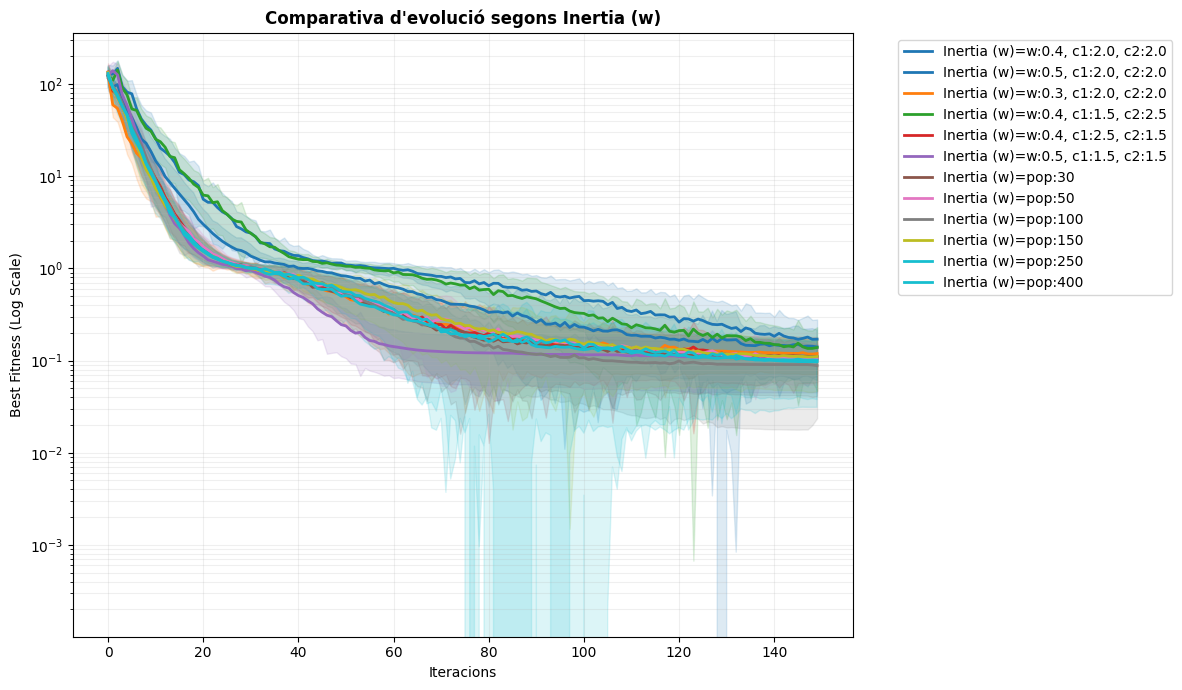

In [6]:
# Configuració bàsica
dimensions = 10
lower_bound = [-600] * dimensions 
upper_bound = [600] * dimensions
rounds_sweep = 30
def_w = 0.4
def_c1 = 2.5
def_c2 = 1.5


results_pso = []

print(f"Initializing Parameter Sweep - Griewank {dimensions}D, w = {def_w}, c1 = {def_c1}, c2 = {def_c2}...")
pop_configs =  [30, 50, 100, 150, 250, 400]


for pop in pop_configs:
    print(f"\nTrying PSO with population {pop}")
    start = time.time()
    result = run_experiment('PSO', griewank, dimensions, lower_bound, upper_bound, {'w': def_w, 'c1': def_c1, 'c2': def_c2}, rounds_sweep, def_iter, def_pop)
    results_pso.append({'Alg': 'PSO', 'population': pop, 'Avg Fit': result['avg'], 'Min Fit': result['min'], 'Std Dev': result['std']})
    label = f"pop:{pop}"
    master_results[label] = result
    print(f"  -> Made in {time.time()-start:.2f}s | Avg: {result['avg']:.4f} | Min: {result['min']:.4f} | Std: {result['std']:.4f}")

df_pso3 = pd.DataFrame(results_pso)
print("\n" + "="*70)
print(" RESULTS PSO - GRIEWANK " + str(dimensions) + "D")
print("="*70)
print(df_pso3.to_string(index=False))

plot_final_comparison(master_results, var_name="Inertia (w)")


Generant la corba de convergència per a w=0.4, c1=2.0, c2=2.0...


C:\Users\Enric\AppData\Local\Temp\ipykernel_13852\506195054.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  final_fitness = float(fitness_history[-1])


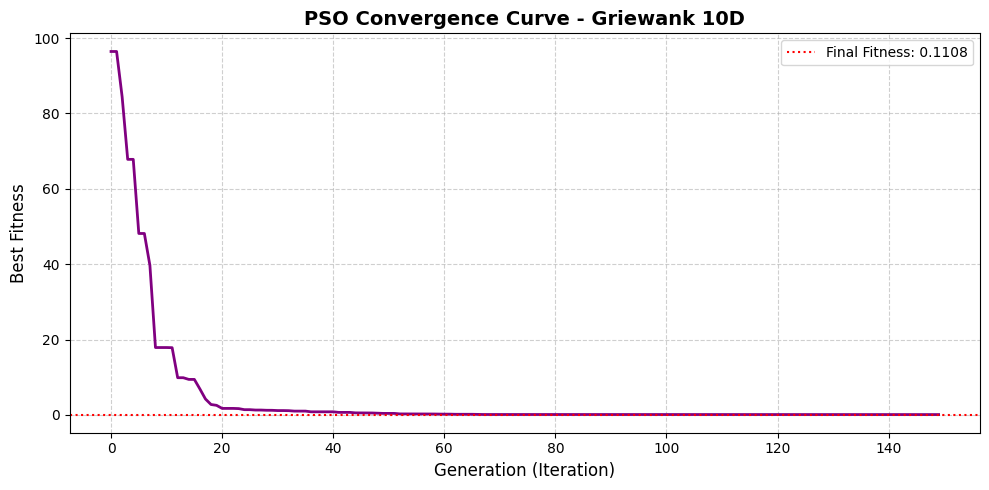

In [21]:
import matplotlib.pyplot as plt

# ==========================================
# PLOT DE CONVERGÈNCIA DEL PSO (GRIEWANK 10D)
# ==========================================

# 1. Posa aquí la configuració guanyadora del teu parameter sweep
best_w = 0.4
best_c1 = 2.0
best_c2 = 2.0

print(f"\nGenerant la corba de convergència per a w={best_w}, c1={best_c1}, c2={best_c2}...")

# 2. Executem el PSO una única vegada amb aquests paràmetres
pso_plot = PSO(func=griewank, n_dim=dimensions, pop=def_pop, max_iter=def_iter, 
               lb=lower_bound, ub=upper_bound, w=best_w, c1=best_c1, c2=best_c2)
pso_plot.run()

# L'historial del millor fitness a cada generació es guarda a gbest_y_hist
fitness_history = pso_plot.gbest_y_hist

# 3. Dibuixem la gràfica
plt.figure(figsize=(10, 5))
plt.plot(fitness_history, color='purple', linewidth=2)

plt.title(f'PSO Convergence Curve - Griewank 10D', fontsize=14, fontweight='bold')
plt.xlabel('Generation (Iteration)', fontsize=12)
plt.ylabel('Best Fitness', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Marquem el valor final obtingut
final_fitness = float(fitness_history[-1])
plt.axhline(y=final_fitness, color='red', linestyle=':', linewidth=1.5, 
            label=f'Final Fitness: {final_fitness:.4f}')
plt.legend()

plt.tight_layout()
plt.savefig(f'PSO_Griewank_Convergence {best_w}_{best_c1}_{best_c2}.png', dpi=300)
plt.show()

🚀 Executant PSO amb record_mode=True per extreure les 3 mètriques...


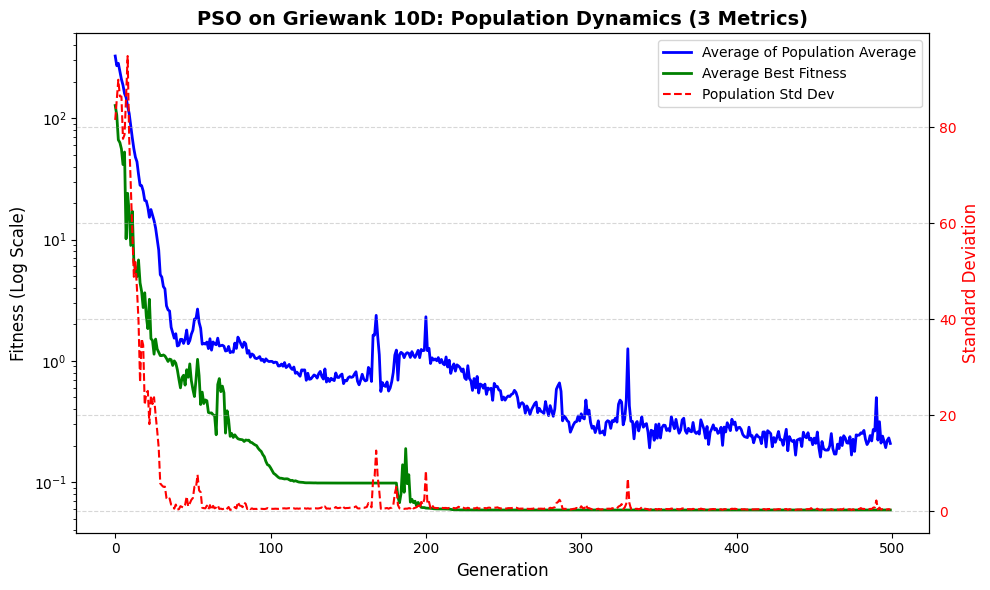

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sko.PSO import PSO

# 1. Definició de la funció Griewank i el calculador per poblacions
def griewank(x):
    part1 = sum(x**2) / 4000.0
    part2 = np.prod(np.cos(x / np.sqrt(np.arange(1, len(x) + 1))))
    return 1.0 + part1 - part2

def calc_fitness_pop(X):
    # Calcula el fitness per a cadascuna de les partícules (files de X)
    return np.array([griewank(ind) for ind in X])

dimensions = 10
lower_bound = [-600] * dimensions
upper_bound = [600] * dimensions
def_pop = 50
def_iter = 500

# Posa aquí la configuració guanyadora del teu escombrat
best_w = 0.4
best_c1 = 2.0
best_c2 = 2.0

print("🚀 Executant PSO amb record_mode=True per extreure les 3 mètriques...")

pso_metrics = PSO(func=griewank, n_dim=dimensions, pop=def_pop, max_iter=def_iter, 
                  lb=lower_bound, ub=upper_bound, w=best_w, c1=best_c1, c2=best_c2)

# ACTIVEM EL MODE RECORD PER GUARDAR L'HISTORIAL DE TOTES LES PARTÍCULES 
pso_metrics.record_mode = True
pso_metrics.run()

# Extraiem l'historial de posicions (X) per a cada generació 
X_history = pso_metrics.record_value['X']

# 2. Calculem les 3 mètriques per a cada generació
avg_fitness_hist = []
best_fitness_hist = []
std_fitness_hist = []

for pop_X in X_history:
    pop_fitness = calc_fitness_pop(pop_X)
    avg_fitness_hist.append(np.mean(pop_fitness))
    best_fitness_hist.append(np.min(pop_fitness))
    std_fitness_hist.append(np.std(pop_fitness))

# 3. CREACIÓ DEL PLOT AMB LES 3 MÈTRIQUES
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Generation', fontsize=12)
ax1.set_ylabel('Fitness (Log Scale)', fontsize=12)
# Usem escala logarítmica perquè l'error cau de milers a gairebé zero molt de pressa
ax1.set_yscale('log') 

# Línies de Mitjana i Millor Fitness
line1, = ax1.plot(avg_fitness_hist, label='Average of Population Average', color='blue', linewidth=2)
line2, = ax1.plot(best_fitness_hist, label='Average Best Fitness', color='green', linewidth=2)

# Segon eix Y (a la dreta) per a la Desviació Estàndard per evitar que quedi esclafada
ax2 = ax1.twinx()
ax2.set_ylabel('Standard Deviation', color='red', fontsize=12)
line3, = ax2.plot(std_fitness_hist, label='Population Std Dev', color='red', linestyle='--', linewidth=1.5)
ax2.tick_params(axis='y', labelcolor='red')

# Unifiquem les llegendes
lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=10)

plt.title('PSO on Griewank 10D: Population Dynamics (3 Metrics)', fontweight='bold', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('PSO_Griewank_3Metrics.png', dpi=300)
plt.show()